# Análise Exploratória de Dados (EDA) - NASA KOI

Este notebook é destinado à etapa de inspeção e Análise Exploratória Inicial do dataset `kepler_koi_cumulative.csv`, conforme as Issues #3 e #4.

In [30]:
!pip install pandas
!pip install matplotlib
!pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
!pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Kepler Objects of Interest (KOI) - dataset
A Cumulative KOI Tabel disponibilizada pela NASA Exoplanet Archive reune informações individuais de KOIs que descrevem os resultados de diferentes buscas nas curvas de luz do Keppler. Por tratar-se de superconjunto é ideal para algoritmos de aprendizado supervisionado.

Problema: Classificação binária supervisionadade objetos de interesse de Kepler (KOI).

Objetivo: O experimento em questão busca treinar o modelo de redes neurais do tipo MLP (Multi-layer Perceptron). Distiguindo através dos dados se o sinal captadado pelo Kepler é um candidato a exoplaneta ou um falso positivo.

Variável escolhida:`koi_pdisposition` 

Justificativa técnica: Define, de acordo com a documentação da NASA, a variável baseia-se unicamente nos dados do kepler a mais indicada para o treinamento da rede neural Diferentemente da tabela `koi_disposition` que possui: FALSE POSITIVE, NOT DISPOSITIONED e  CANDIDATE, a `koi_pdisposition` possui apenas duas saídas: CANDIDATE e FALSE POSITIVE  o que aumentaria a complexidade para a rede. Dessa maneira, é possível ajustar os pesos adequadamente para padrões físicos e ruídos dos exoplanetas



In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações básicas de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [33]:
import pandas as pd

url = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv'
koi = pd.read_csv(url)
koi.head() # carrega csv

,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,...,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,10797460,K00752.01,Kepler-227 b,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,93.59,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000
1,10797460,K00752.02,Kepler-227 c,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,9.11,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969
2,10811496,K00753.01,NaN,297.00482,0.0,19h48m01.16s,48.134129,0.0,+48d08m02.9s,15.943,...,0,0,39.30,31.04,-10.49,7.29555,35.03293,-2.75453,LS+MCMC,0.000
3,10848459,K00754.01,NaN,285.53461,0.0,19h02m08.31s,48.285210,0.0,+48d17m06.8s,16.100,...,0,0,891.96,668.95,-230.35,0.22080,0.00917,-0.01837,LS+MCMC,0.000
4,10854555,K00755.01,Kepler-664 b,288.75488,0.0,19h15m01.17s,48.226200,0.0,+48d13m34.3s,16.015,...,0,0,926.16,874.33,-314.24,1.98635,2.71141,-1.74541,LS+MCMC,1.000


In [34]:
print(f"A base possui {koi.shape[0]} linhas e {koi.shape[1]} colunas")

A base possui 9564 linhas e 153 colunas


In [35]:
koi.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 153 entries, kepid to koi_score
dtypes: float64(127), int64(6), object(1), str(19)
memory usage: 11.2+ MB


In [36]:
print(koi.dtypes)

kepid              int64
kepoi_name           str
kepler_name          str
ra               float64
ra_err           float64
                  ...   
koi_srho         float64
koi_srho_err1    float64
koi_srho_err2    float64
koi_fittype          str
koi_score        float64
Length: 153, dtype: object


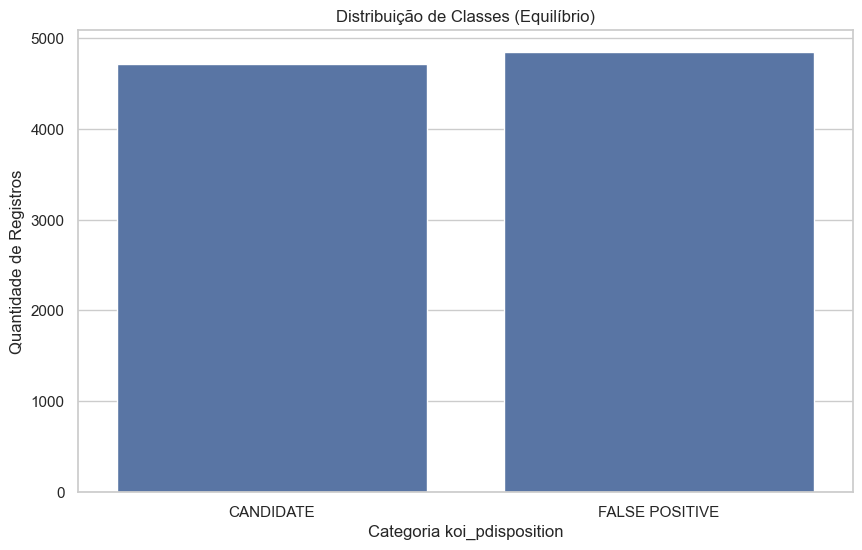

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# quantos registros existem para a categoria da coluna

plt.title('Distribuição de Classes (Equilíbrio)')
sns.countplot(data=koi, x='koi_pdisposition')
plt.xlabel('Categoria koi_pdisposition')
plt.ylabel('Quantidade de Registros')
plt.show()

In [38]:
vazios = koi.isnull().sum()
print("Colunas com dados ausentes")
print(vazios[vazios > 0])

Colunas com dados ausentes
kepler_name       6817
koi_gmag            41
koi_gmag_err      9564
koi_rmag             9
koi_rmag_err      9564
                  ... 
koi_insol_err2     321
koi_srho           321
koi_srho_err1      321
koi_srho_err2      321
koi_score         1510
Length: 128, dtype: int64


In [39]:
print("\nColunas com mais valores vazios")

koi.isnull().sum()

koi.isnull().sum().sort_values(ascending=False).head(10)


Colunas com mais valores vazios


koi_gmag_err      9564
koi_imag_err      9564
koi_zmag_err      9564
koi_rmag_err      9564
koi_kepmag_err    9564
koi_longp_err2    9564
koi_sage_err2     9564
koi_sage_err1     9564
koi_sage          9564
koi_sma_err1      9564
dtype: int64

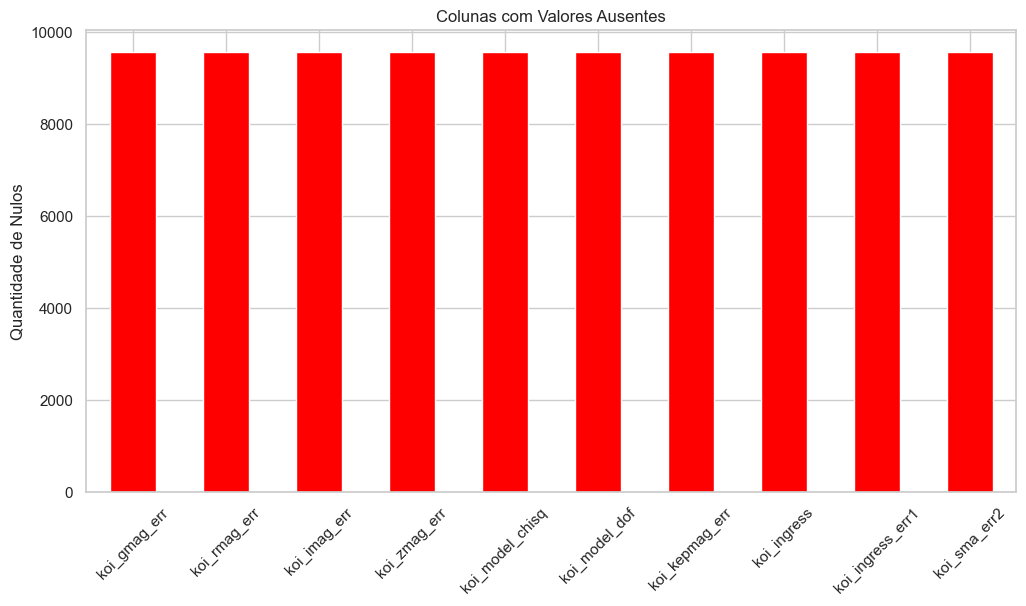

In [40]:
# Gráfico das colunas com mais valores nulos
plt.figure(figsize=(12, 6))
vazios[vazios > 0].sort_values(ascending=False).head(10).plot(kind='bar', color='red')
plt.title('Colunas com Valores Ausentes')
plt.ylabel('Quantidade de Nulos')
plt.xticks(rotation=45)
plt.show()

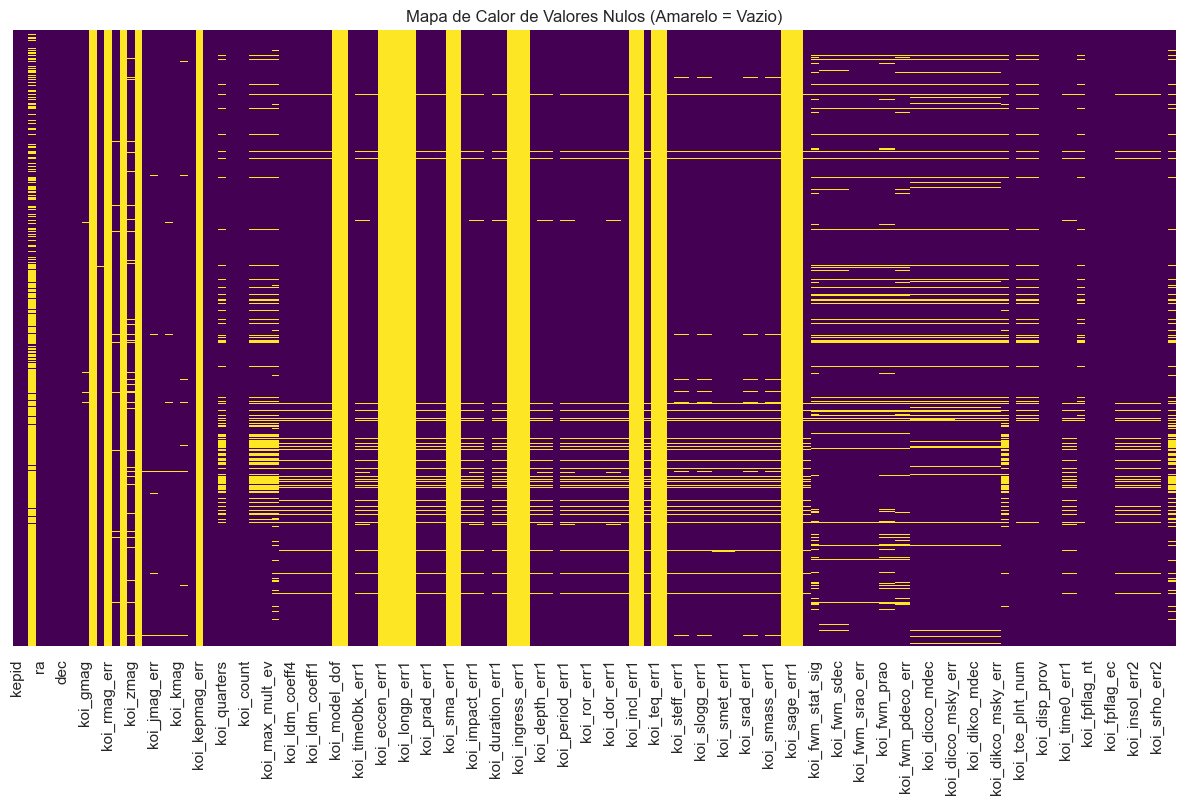

In [41]:
# Visualizando dos dados nulos 
plt.figure(figsize=(15, 8))
sns.heatmap(koi.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos (Amarelo = Vazio)')
plt.show()

In [42]:
koi.nunique()


kepid            8214
kepoi_name       9564
kepler_name      2747
ra               8131
ra_err              1
                 ... 
koi_srho         9002
koi_srho_err1    8320
koi_srho_err2    7994
koi_fittype         4
koi_score         650
Length: 153, dtype: int64

In [43]:
print("Quantidade de valores únicos por coluna")
print(koi.nunique().sort_values())

Quantidade de valores únicos por coluna
koi_rmag_err           0
koi_imag_err           0
koi_gmag_err           0
koi_zmag_err           0
koi_kepmag_err         0
                    ... 
koi_fwm_sra         9030
koi_datalink_dvs    9218
koi_time0bk         9538
kepoi_name          9564
koi_period          9564
Length: 153, dtype: int64


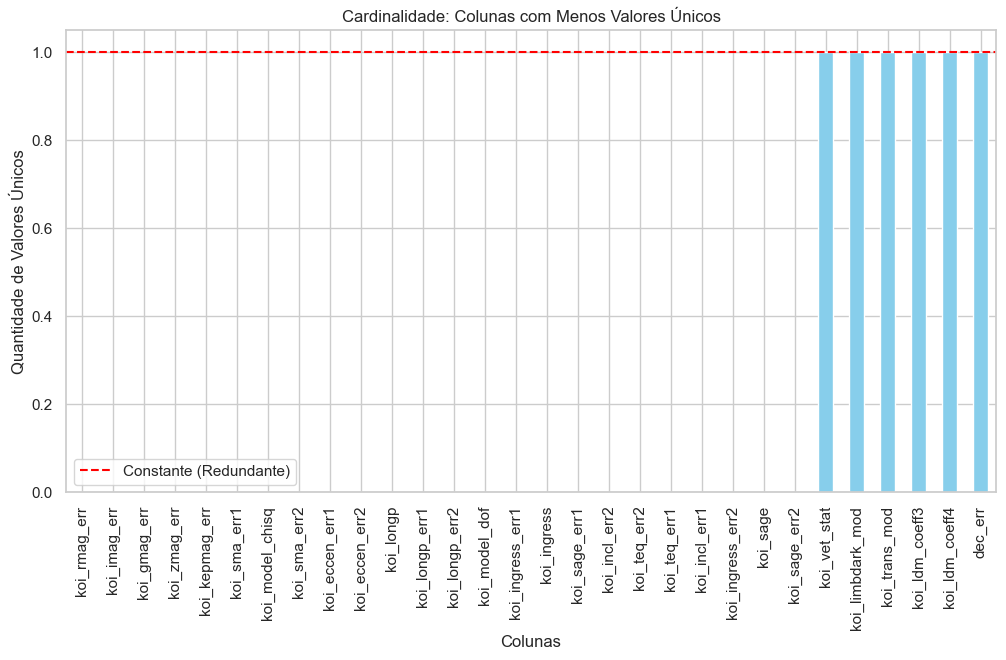

In [44]:
# Criando a série de dados únicos
unicos = koi.nunique().sort_values()

# Gráfico de barras para as colunas com poucos valores únicos (Categorias e Constantes)
plt.figure(figsize=(12, 6))
unicos.head(30).plot(kind='bar', color='skyblue')
plt.title('Cardinalidade: Colunas com Menos Valores Únicos')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de Valores Únicos')
plt.xticks(rotation=90)
plt.axhline(y=1, color='red', linestyle='--', label='Constante (Redundante)')
plt.legend()
plt.show()

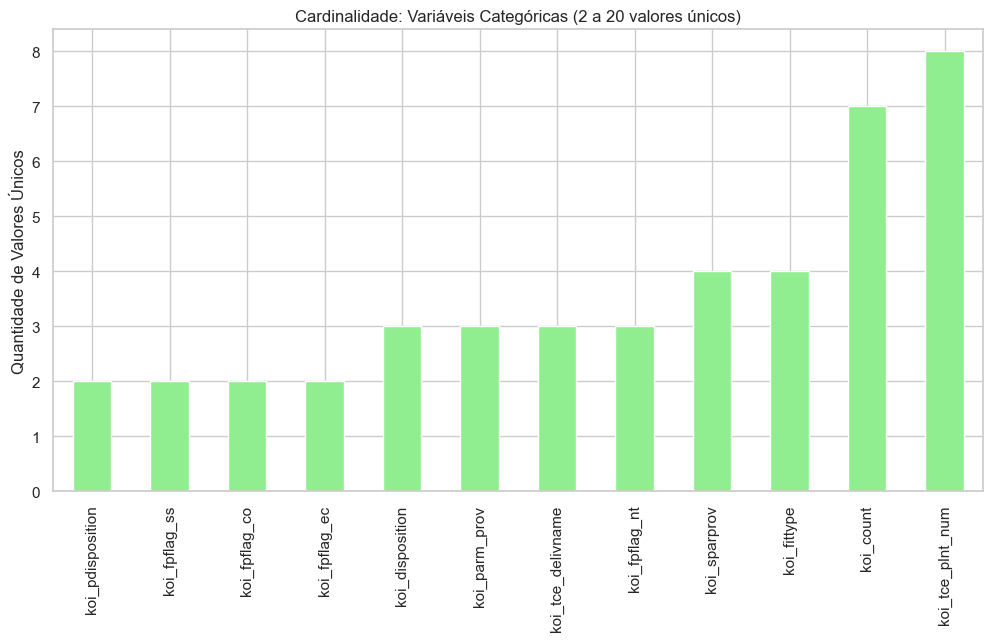

In [45]:
# Gráfico apenas de quem tem entre 2 e 20 valores únicos (Categorias Reais)
categorias = unicos[(unicos > 1) & (unicos <= 20)]

plt.figure(figsize=(12, 6))
categorias.plot(kind='bar', color='lightgreen')
plt.title('Cardinalidade: Variáveis Categóricas (2 a 20 valores únicos)')
plt.ylabel('Quantidade de Valores Únicos')
plt.show()

In [46]:
# exibindo as métricas da tabela
koi.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
kepid,9564.0,7.690628e+06,2.653459e+06,757450.000000,5.556034e+06,7.906892e+06,9.873066e+06,1.293514e+07
ra,9564.0,2.920602e+02,4.766657e+00,279.852720,2.886608e+02,2.922611e+02,2.958592e+02,3.017208e+02
ra_err,9564.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dec,9564.0,4.381043e+01,3.601243e+00,36.577381,4.077717e+01,4.367750e+01,4.671461e+01,5.233601e+01
dec_err,9564.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
koi_gmag,9523.0,1.483050e+01,1.501885e+00,7.225000,1.389650e+01,1.506400e+01,1.593550e+01,2.115000e+01
koi_gmag_err,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_rmag,9555.0,1.422156e+01,1.383713e+00,7.101000,1.339300e+01,1.447100e+01,1.527500e+01,1.996000e+01
koi_rmag_err,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_imag,9410.0,1.407514e+01,1.292573e+00,7.627000,1.329400e+01,1.431750e+01,1.506300e+01,1.990000e+01


# Análise de integridade e relevância dos dados
Contendo originalmente 153 colunas diversas delas possuem linhas vazias:

*   Colunas com 9564 valores nulos como no caso de `koi_sage` devem ser removidas.

## Variedade (Cardinalidade)
* Colunas com apenas um valor único 
tornam-se redundantes.
* Colunas com alta cardinalidade como `kepoi_name` e `koi_period`não auxiliam na análise da rede.

In [47]:
# identificação onde tudo é nulo
colunas_vazias = koi.columns[koi.isnull().all()]

colunas_constantes = [ col for col in koi.columns if koi[col].nunique() <=1]

colunas_id = ['kepid', 'kepoi_name', 'kepler_name']

colunas_remover = list(set(list(colunas_vazias) + colunas_constantes + colunas_id))

print(f"Total de colunas identificadas para remoção: {len(colunas_remover)}")

# remoção das linhas

koi.drop(columns=colunas_remover, inplace=True, errors='ignore')

print(f"Colunas removidas: {len(colunas_remover)}")
print(f"Colunas restants: {len(koi.columns)}")

Total de colunas identificadas para remoção: 38
Colunas removidas: 38
Colunas restants: 115


In [48]:
koi.head()

,ra,ra_str,dec,dec_str,koi_gmag,koi_rmag,koi_imag,koi_zmag,koi_jmag,koi_jmag_err,...,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,291.93423,19h27m44.22s,48.141651,+48d08m29.9s,15.890,15.270,15.114,15.006,14.082,0.025,...,0,0,93.59,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000
1,291.93423,19h27m44.22s,48.141651,+48d08m29.9s,15.890,15.270,15.114,15.006,14.082,0.025,...,0,0,9.11,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969
2,297.00482,19h48m01.16s,48.134129,+48d08m02.9s,15.943,15.390,15.220,15.166,14.254,0.028,...,0,0,39.30,31.04,-10.49,7.29555,35.03293,-2.75453,LS+MCMC,0.000
3,285.53461,19h02m08.31s,48.285210,+48d17m06.8s,16.100,15.554,15.382,15.266,14.326,0.035,...,0,0,891.96,668.95,-230.35,0.22080,0.00917,-0.01837,LS+MCMC,0.000
4,288.75488,19h15m01.17s,48.226200,+48d13m34.3s,16.015,15.468,15.292,15.241,14.366,0.033,...,0,0,926.16,874.33,-314.24,1.98635,2.71141,-1.74541,LS+MCMC,1.000


In [49]:
koi.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 115 entries, ra to koi_score
dtypes: float64(98), int64(5), object(1), str(11)
memory usage: 8.4+ MB


koi_pdisposition
FALSE POSITIVE    4847
CANDIDATE         4717
Name: count, dtype: int64


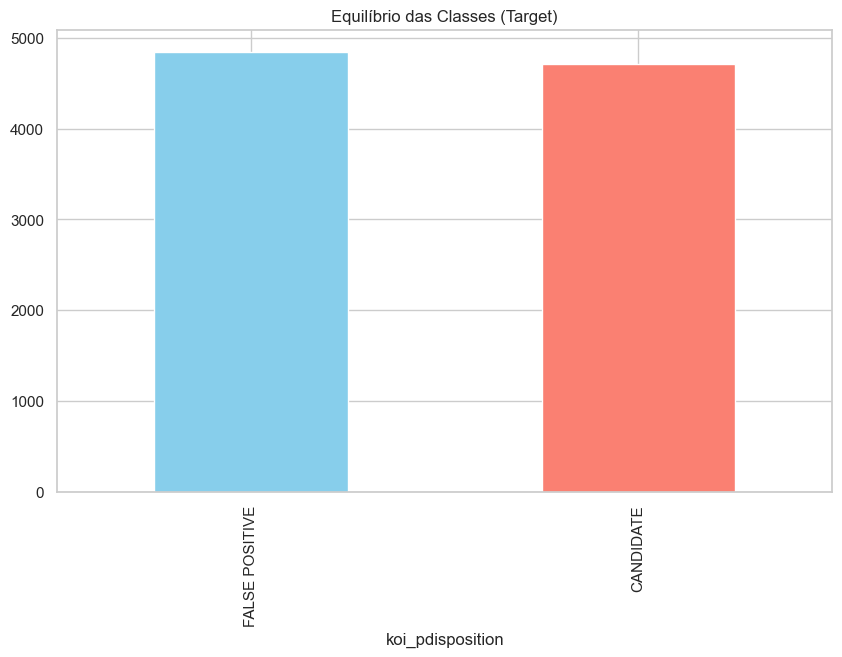

In [50]:
# verificando o equilíbrio das classes
print(koi['koi_pdisposition'].value_counts())
koi['koi_pdisposition'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Equilíbrio das Classes (Target)')
plt.show()

A rede neural identifica somente números binários (0,1) logo FALSE POSITIVE e CANDIDATE devem ser alteradas para a compreensão.

In [51]:
koi['koi_pdisposition'] = koi['koi_pdisposition'].map({'FALSE POSITIVE': 0, 'CANDIDATE': 1})

print("Target atualizado:")
print(koi['koi_pdisposition'].value_counts())

Target atualizado:
koi_pdisposition
0    4847
1    4717
Name: count, dtype: int64


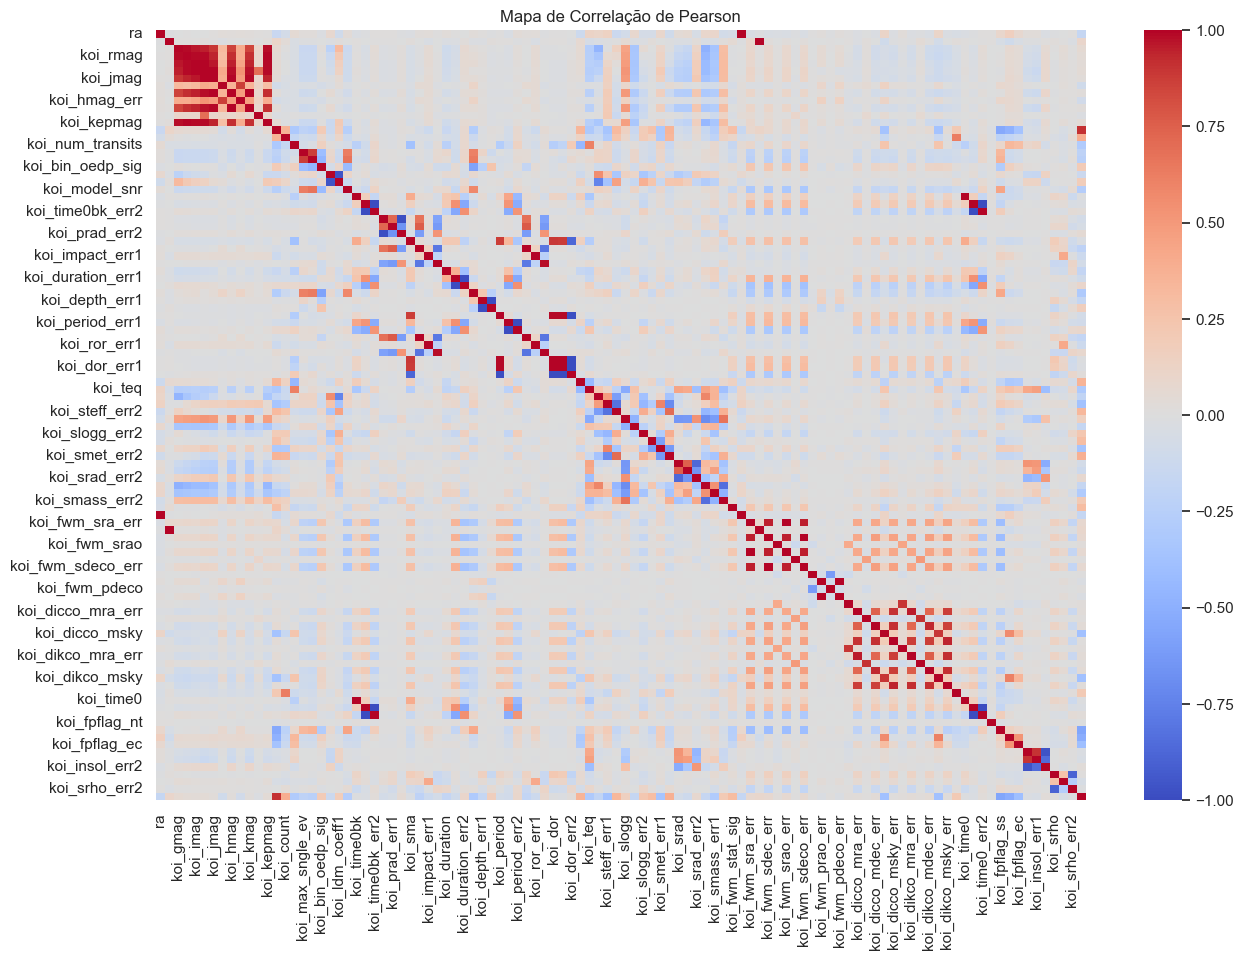

In [52]:
# verificação para features redundantes
plt.figure(figsize=(15,10))
sns.heatmap(koi.select_dtypes(include=['number']).corr(), cmap='coolwarm', annot=False)
plt.title('Mapa de Correlação de Pearson')
plt.show()

As colunas com muitas redundâncias devem ser removidas

In [53]:
cols_redundantes = ['koi_gmag', 'koi_rmag', 'koi_imag', 'koi_zmag', 'koi_jmag', 'koi_hmag', 'koi_kmag']

# Dropando as redundantes
koi = koi.drop(columns=cols_redundantes, errors='ignore')
print(f"Colunas restantes após remover redundâncias: {len(koi.columns)}")

Colunas restantes após remover redundâncias: 108


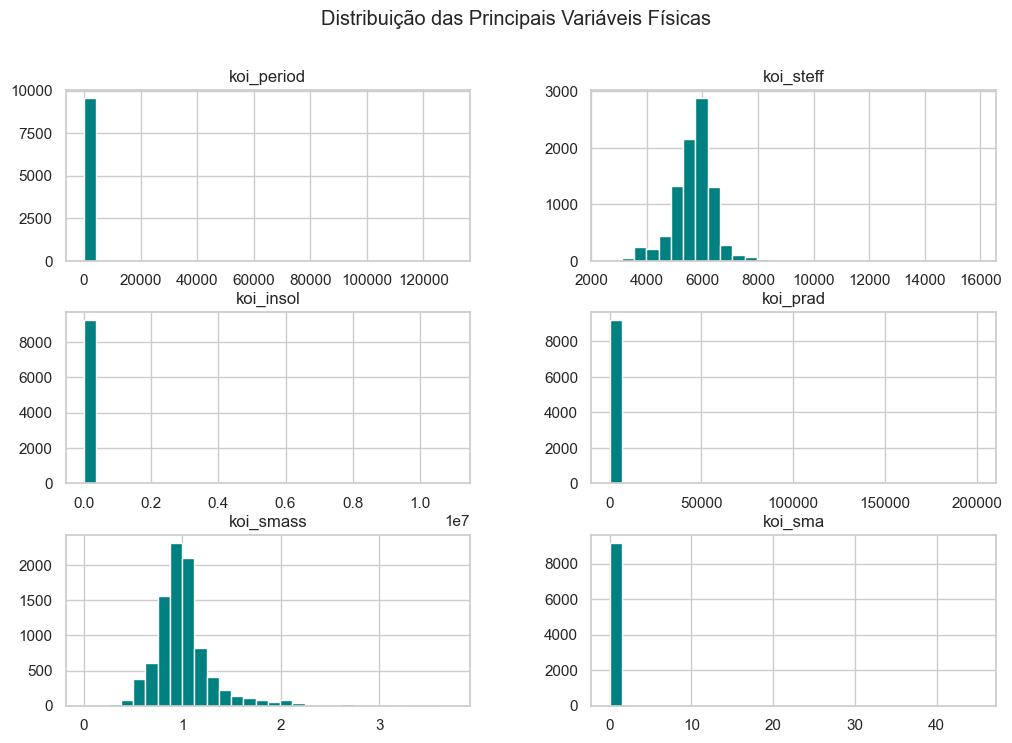

In [54]:

colunas_chave = ['koi_period', 'koi_steff', 'koi_insol', 'koi_prad', 'koi_smass', 'koi_sma']
koi[colunas_chave].hist(bins=30, figsize=(12, 8), color='teal')
plt.suptitle('Distribuição das Principais Variáveis Físicas')
plt.show()

In [55]:
koi = koi.select_dtypes(include=['number'])

koi = koi.fillna(koi.median())

print("Total de nulos no dataset final:", koi.isnull().sum().sum())

Total de nulos no dataset final: 0
